In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
import os
print(os.getcwd())

C:\Users\ahyo\IDXExchange\IDXExchange


## Week 1: Orientation and Setup

Note on keys: The following fields are considered `InKeyIndex` fields and may be queried in batches up to 300,000 at a time: `ListingId` , `ListingKey` , `ModificationTimestamp` , `PhotosChangeTimestamp` , `PhotosCount` , `PostalCode` , `StandardStatus`.

| Key name | Key type | Description |
|---|---|---|
|`ListingId`| String | Well-known identifier for listing. Intended for human use for retrieving listings. |
|`ListingKey`| String | Unique identifier of listing from immediate source. |
| `ModificationTimestamp` | DateTimeOffset | System generated timestamp of last modification |
| `PhotosChangeTimestamp` | DateTimeOffset | System generated timestamp of update/change to photos |
| `PhotosCount` | Int32 | Total number of pictures included with listing |
| `PostalCode` | String | Postal code |
| `StandardStatus` | StandardStatus Enum | Current status of listing |

In [3]:
keys = ['ListingId', 'ListingKey', 'ModificationTimestamp', 'PhotosChangeTimestamp', 'PhotosCount', 'PostalCode', 'StandardStatus']

In [4]:
dp = Path('../data/')
csv_names = []
for item in dp.iterdir():
    if item.is_file():
        print(item.name)
        csv_names.append(item.name)

CRMLSSold20220101_20231231_filled.csv
CRMLSSold202401_filled.csv
CRMLSSold202402_filled.csv
CRMLSSold202403_filled.csv
CRMLSSold202404_filled.csv
CRMLSSold202405_filled.csv
CRMLSSold202406_filled.csv
CRMLSSold202407_filled.csv
CRMLSSold202408.csv
CRMLSSold202409.csv
CRMLSSold202410.csv
CRMLSSold202411.csv
CRMLSSold202412.csv
CRMLSSold202501_filled.csv
CRMLSSold202502.csv
CRMLSSold202503.csv
CRMLSSold202504.csv
CRMLSSold202505.csv
CRMLSSold202506.csv
CRMLSSold202507.csv
CRMLSSold202508.csv
CRMLSSold202509.csv
CRMLSSold202510.csv
CRMLSSold202511.csv
CRMLSSold202512.csv
CRMLSSold202601.csv
CRMLSSold202602.csv
CRMLSSold202603.csv
CRMLSSold202604.csv
CRMLSSold202605.csv


In [5]:
df_names = ["CRMLSSold202401_filled.csv", "CRMLSSold202402_filled.csv", "CRMLSSold202403_filled.csv", "CRMLSSold202404_filled.csv", 
            "CRMLSSold202405_filled.csv", "CRMLSSold202406_filled.csv", "CRMLSSold202407_filled.csv"]

In [16]:
df = pd.DataFrame()
for name in df_names:
    path = Path("../data/" + name)
    df2 = pd.read_csv(path)
    #print(len(df2))
    df = pd.concat([df, df2], join='outer', ignore_index=True)
    #print(len(df))
df = df[df['PropertyType'] == 'Residential']
df = df[df['PropertySubType'] == 'SingleFamilyResidence']
df.head()

C:\Users\ahyo\AppData\Local\Temp\ipykernel_24484\3027032021.py:4: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(path)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
5,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,2.0,NaN,91950,NaN,NaN,NaN,True,True,NaN,NaN
9,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,2.0,NaN,91950,NaN,NaN,NaN,True,True,NaN,NaN
28,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,...,3.0,San Luis Coastal Unified,93401,0.0,11219.0,NaN,False,False,NaN,NaN
29,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,...,2.0,NaN,95437,NaN,74487.6,NaN,False,False,NaN,NaN
31,"Tile,Wood",True,NaN,NaN,NaN,NaN,1061988701,dannyduong@gmail.com,2024-01-31,2340000.0,...,3.0,Other,95148,NaN,8712.0,NaN,True,True,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82019 entries, 5 to 162846
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Flooring                      52550 non-null  object 
 1   ViewYN                        74894 non-null  object 
 2   WaterfrontYN                  35 non-null     object 
 3   BasementYN                    1886 non-null   object 
 4   PoolPrivateYN                 72481 non-null  object 
 5   OriginalListPrice             81860 non-null  float64
 6   ListingKey                    82019 non-null  int64  
 7   ListAgentEmail                81938 non-null  object 
 8   CloseDate                     82019 non-null  object 
 9   ClosePrice                    82018 non-null  float64
 10  ListAgentFirstName            81226 non-null  object 
 11  ListAgentLastName             82016 non-null  object 
 12  Latitude                      81947 non-null  float64
 13  Longi

In [8]:
price_cols = ['OriginalListPrice', 'ClosePrice', 'ListPrice']
df.sort_values('ClosePrice', ascending=False)[price_cols].head(10)

,OriginalListPrice,ClosePrice,ListPrice
84328,78000000.0,62800000.0,78000000.0
51602,40000000.0,38450000.0,40000000.0
86491,38000000.0,38000000.0,38000000.0
113144,45000000.0,37110000.0,45000000.0
83829,37500000.0,35000000.0,37500000.0
151396,34000000.0,32300000.0,34000000.0
161504,38000000.0,32000000.0,38000000.0
27619,39500000.0,31900000.0,39500000.0
6468,32000000.0,31000000.0,32000000.0
136222,38500000.0,30250000.0,33000000.0


In [9]:
df[price_cols].describe()

,OriginalListPrice,ClosePrice,ListPrice
count,8.186000e+04,8.201800e+04,8.201900e+04
mean,1.298199e+06,1.260247e+06,1.247561e+06
std,4.413827e+06,1.329303e+06,1.407689e+06
min,1.100000e+00,3.450000e+02,6.950000e+02
25%,6.200000e+05,6.200000e+05,6.150000e+05
50%,8.950000e+05,9.000000e+05,8.898880e+05
75%,1.444000e+06,1.465000e+06,1.400000e+06
max,7.759000e+08,6.280000e+07,7.800000e+07


## Week 2: Data Exploration

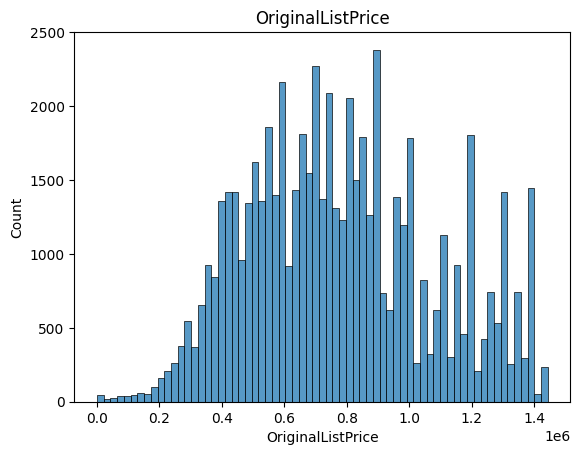

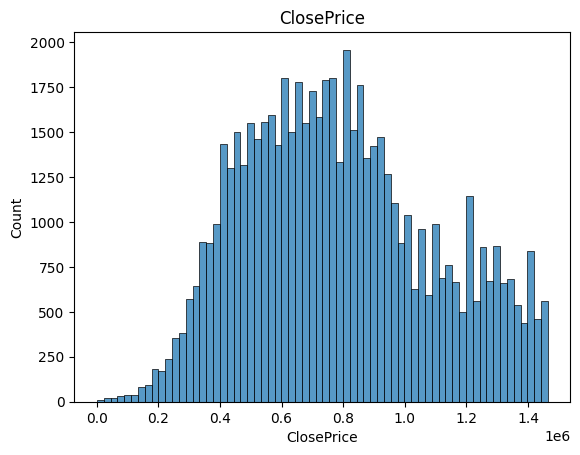

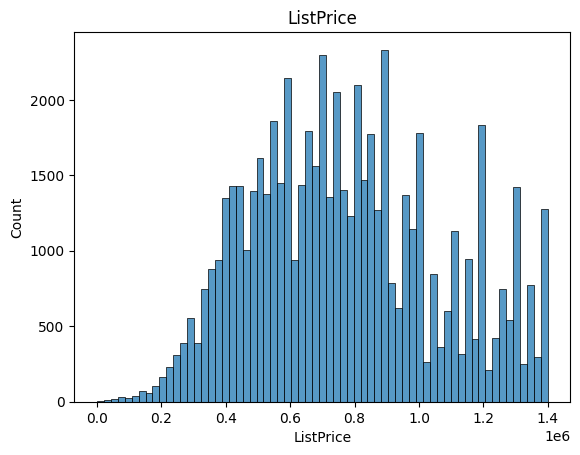

In [10]:
for c in price_cols:
    plt.figure()
    sns.histplot(df[df[c] < df[c].quantile(0.75)][c])
    plt.title(c)
    plt.show()

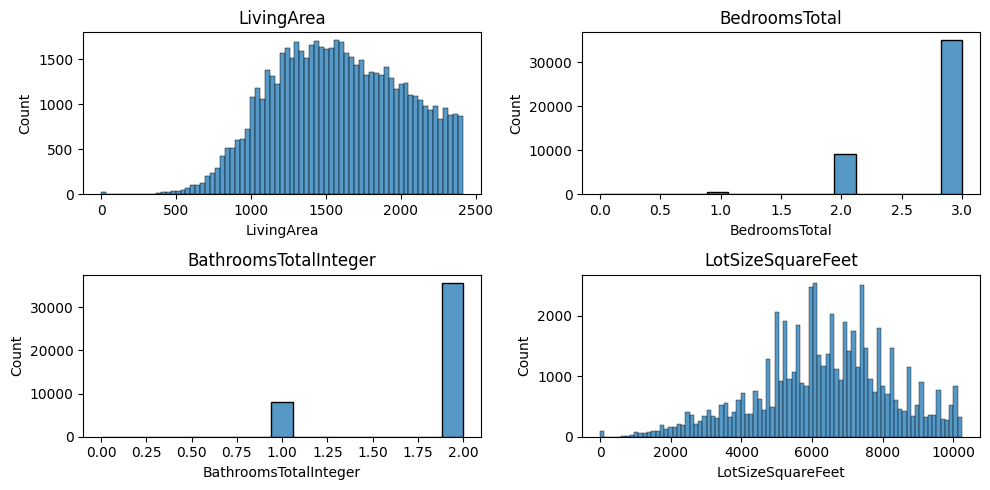

In [11]:
other_cols = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']
fig, axes = plt.subplots(2, 2, figsize=(10,5))
for i,c in enumerate(other_cols):
    sns.histplot(df[df[c] < df[c].quantile(0.75)][c], ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(c)
plt.tight_layout()
plt.show()

In [12]:
df[other_cols].describe()

,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,81972.000000,82019.000000,81997.000000,8.063600e+04
mean,2028.046845,3.472744,2.605595,1.572887e+05
std,1111.995367,0.950260,1.268220,9.313375e+06
min,0.000000,0.000000,0.000000,0.000000e+00
25%,1367.000000,3.000000,2.000000,5.663000e+03
50%,1798.000000,3.000000,2.000000,7.230000e+03
75%,2415.000000,4.000000,3.000000,1.025025e+04
max,123764.000000,34.000000,175.000000,1.633500e+09


## Week 3: Data Preprocessing

In [17]:
# keep columns with at least 50% non-null values
df_cleaned = df.dropna(thresh=len(df) * 0.50, axis=1)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82019 entries, 5 to 162846
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Flooring                     52550 non-null  object 
 1   ViewYN                       74894 non-null  object 
 2   PoolPrivateYN                72481 non-null  object 
 3   OriginalListPrice            81860 non-null  float64
 4   ListingKey                   82019 non-null  int64  
 5   ListAgentEmail               81938 non-null  object 
 6   CloseDate                    82019 non-null  object 
 7   ClosePrice                   82018 non-null  float64
 8   ListAgentFirstName           81226 non-null  object 
 9   ListAgentLastName            82016 non-null  object 
 10  Latitude                     81947 non-null  float64
 11  Longitude                    81947 non-null  float64
 12  UnparsedAddress              81943 non-null  object 
 13  PropertyType        